In [ ]:
#Синонимическая близость и алгебраические операции над векторами

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pymorphy2
import numpy as np
import pandas as pd
import re
import nltk
#import spacy
import string
import pymorphy2

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 42.0 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=24fbc0bafb277c670e3a14417d0cab2dec02f54dd726c5128a13052b60c86ef5
  Stored in directory: /root/.cache/pip/wheels/fc/ab/d4/5da2067ac95b36618c629a5f93f809425700506f72c9732fac
Successfully built docopt


In [3]:
##Чтение датасета с текстом
df = pd.read_excel("/content/drive/MyDrive/preprocessed_lenta_titles.xlsx")
df.head()

,Unnamed: 0,title,tags,text_lower,text_punct,text_stop,text_common,text_rare,text_nonum,text_token,text_lemm,text_ready
0,0,В Курской области объявили опасность атаки БПЛА,Происшествия,в курской области объявили опасность атаки бпла,в курской области объявили опасность атаки бпла,курской области объявили опасность атаки бпла,курской объявили опасность атаки бпла,курской объявили опасность атаки бпла,курской объявили опасность атаки бпла,"['курской', 'объявили', 'опасность', 'атаки', ...",курский объявить опасность атака бпнуть,курский область объявить опасность атака бпнуть
1,1,Юристы прокомментировали иск пострадавших в от...,Следствие и суд,юристы прокомментировали иск пострадавших в от...,юристы прокомментировали иск пострадавших в от...,юристы прокомментировали иск пострадавших отно...,юристы прокомментировали иск пострадавших отно...,юристы прокомментировали иск пострадавших отно...,юристы прокомментировали иск пострадавших отно...,"['юристы', 'прокомментировали', 'иск', 'постра...",юрист прокомментировать иск пострадать отношен...,юрист прокомментировать иск пострадать отношен...
2,2,На Западе рассказали о нехватке Patriot для пе...,Политика,на западе рассказали о нехватке patriot для пе...,на западе рассказали о нехватке patriot для пе...,западе рассказали нехватке patriot передачи всу,западе нехватке patriot передачи,западе нехватке patriot передачи,западе нехватке patriot передачи,"['западе', 'нехватке', 'patriot', 'передачи']",запад нехватка patriot передача,запад рассказать нехватка patriot передача всу
3,3,Очередные российские спортсмены отказались от ...,Летние виды,очередные российские спортсмены отказались от ...,очередные российские спортсмены отказались от ...,очередные российские спортсмены отказались уча...,очередные спортсмены отказались участия олимпиаде,очередные спортсмены отказались участия олимпиаде,очередные спортсмены отказались участия олимпиаде,"['очередные', 'спортсмены', 'отказались', 'уча...",очередной спортсмен отказаться участие олимпиада,очередной российский спортсмен отказаться учас...
4,4,Байден и Си Цзиньпин обсудили ситуацию вокруг ...,Политика,байден и си цзиньпин обсудили ситуацию вокруг ...,байден и си цзиньпин обсудили ситуацию вокруг ...,байден си цзиньпин обсудили ситуацию вокруг ti...,байден си цзиньпин обсудили ситуацию вокруг ti...,байден си цзиньпин обсудили ситуацию вокруг ti...,байден си цзиньпин обсудили ситуацию вокруг ti...,"['байден', 'си', 'цзиньпин', 'обсудили', 'ситу...",байден си цзиньпин обсудить ситуация вокруг ti...,байден си цзиньпин обсудить ситуация вокруг ti...


In [4]:
nltk.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('russian'))
# функция, удаляющая стопслова из текстов
def stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])
# Удаление эмодзи
def emoji(string):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', string)
#Удаление URL
# Function for url's
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)
from bs4 import BeautifulSoup
#Function for removing html
def html(text):
    return BeautifulSoup(text, "lxml").text
#Можно выполнить при помощи NLTK. Заодно проведем лемматизацию
from pymorphy2 import MorphAnalyzer
from nltk import sent_tokenize, word_tokenize, regexp_tokenize

def tokenize_lemmas(sent, pat=r"(?u)\b\w\w+\b", morph=MorphAnalyzer()):
    return [morph.parse(tok)[0].normal_form
            for tok in regexp_tokenize(sent, pat)]


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
pd.options.mode.copy_on_write = True
#df['text_ready']  = df['review'].str.lower()
#df['text_ready'] = df['text_ready'].str.replace('\d+', '')
#df['text_ready'] = df['text_ready'].str.replace('[^\w\s]','')
#df["text_ready"] = df["text_ready"].apply(stopwords)
#df['text_ready'] = df['text_ready'].apply(emoji)
#df['text_ready'] = df['text_ready'].apply(remove_urls)
#df['text_ready'] = df['text_ready'].apply(html)
#df["text_ready"] = df["text_ready"].map(lambda x: " ".join(tokenize_lemmas(x)))
df[['text_ready']].dropna(inplace=True)
df[['text_ready']].head()

,text_ready
0,курский область объявить опасность атака бпнуть
1,юрист прокомментировать иск пострадать отношен...
2,запад рассказать нехватка patriot передача всу
3,очередной российский спортсмен отказаться учас...
4,байден си цзиньпин обсудить ситуация вокруг ti...


In [6]:
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence

In [7]:
w2v_model = Word2Vec(
    min_count=5,
    window=5,
    vector_size=1000,
    negative=5,
    workers=24,
    alpha=0.03,
    min_alpha=0.0007,
    sample=6e-5,
    sg=1)
#vector_size — размер векторного представления слова (word embedding).
#negative — сколько неконтекстных слов учитывать в обучении, используя negative sampling.
#alpha — начальный learning_rate, используемый в алгоритме обратного распространения ошибки (Backpropogation).
#min_alpha — минимальное значение learning_rate, на которое может опуститься в процессе обучения.
#sg — если 1, то используется реализация Skip-gram; если 0, то CBOW.

In [8]:
#Получаем лист слов
from nltk.tokenize import sent_tokenize
from gensim.utils import simple_preprocess

class MySentences(object):
    def __init__(self, docs):
        self.corpus = docs
    def __iter__(self):
        for doc in self.corpus:
            doc_sentences = sent_tokenize(doc)
            for sent in doc_sentences:
                yield simple_preprocess(sent) # yields a tokenized

In [9]:
sentences = MySentences(df['text_ready'].astype(str))

In [10]:
#Получаем словарь
nltk.download('punkt_tab')
w2v_model.build_vocab(sentences)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [11]:
#Обучение
w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=5, report_delay=1)

(1215112, 2342745)

In [12]:
#для сохранения оперативной памяти можно написать следующее
w2v_model.init_sims(replace=True)

<ipython-input-12-ccdb4c4f0af4>:2: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  w2v_model.init_sims(replace=True)


In [13]:
w2v_model.wv.most_similar(positive=["опасность"], topn=30)

[('надвигаться', 0.9968568086624146),
 ('обломок', 0.9959230422973633),
 ('сирена', 0.9958741664886475),
 ('красноярский', 0.9958153963088989),
 ('прозвучать', 0.9957076907157898),
 ('столица', 0.9955825209617615),
 ('сработать', 0.9955426454544067),
 ('предупредить', 0.9954801201820374),
 ('хабаровский', 0.9954788684844971),
 ('граничить', 0.9954774379730225),
 ('липецкий', 0.9954709410667419),
 ('татарстан', 0.9954549074172974),
 ('газопровод', 0.995428740978241),
 ('выпустить', 0.9953814744949341),
 ('подвергнуться', 0.9953683614730835),
 ('сутки', 0.995363712310791),
 ('перехватить', 0.9952977895736694),
 ('кубань', 0.9952975511550903),
 ('падение', 0.9952799081802368),
 ('взорваться', 0.9952786564826965),
 ('ураган', 0.9952610731124878),
 ('vampire', 0.9952569007873535),
 ('реактивный', 0.9952561855316162),
 ('звук', 0.9952545762062073),
 ('нефтезавод', 0.9952509999275208),
 ('вампир', 0.9952342510223389),
 ('гладков', 0.9952261447906494),
 ('шебекино', 0.995191752910614),
 ('угро

In [14]:
w2v_model.wv.most_similar(positive=["украина","сша","россия"], topn=50)

[('заявить', 0.995356559753418),
 ('нато', 0.9939718842506409),
 ('мид', 0.9876341819763184),
 ('ес', 0.9860658049583435),
 ('санкция', 0.9838409423828125),
 ('ядерный', 0.9804681539535522),
 ('переговоры', 0.9801113605499268),
 ('путин', 0.9798680543899536),
 ('запад', 0.9794310331344604),
 ('против', 0.9793486595153809),
 ('зеленский', 0.9783770442008972),
 ('оценить', 0.9776272773742676),
 ('ответить', 0.9771339297294617),
 ('оружие', 0.9769980907440186),
 ('киев', 0.9758138656616211),
 ('призвать', 0.9748560786247253),
 ('конфликт', 0.9741860628128052),
 ('иран', 0.9719752073287964),
 ('кремль', 0.9701560735702515),
 ('готовность', 0.9699714779853821),
 ('вопрос', 0.9697927236557007),
 ('вступление', 0.969684362411499),
 ('макрон', 0.9695330858230591),
 ('война', 0.9690566062927246),
 ('поставка', 0.9687856435775757),
 ('израиль', 0.9683918952941895),
 ('германия', 0.9683670997619629),
 ('ответ', 0.968177318572998),
 ('план', 0.9674162864685059),
 ('оон', 0.9670739769935608),
 ('от

In [15]:
#Векторы можно складывать и вычитать. Например, рассмотрим такой вариант: “товар” + “продавец” — “ужасный”:
w2v_model.wv.most_similar(positive=["украина","сша","россия"], negative=["опасность"], topn=100)

[('заявить', 0.9622087478637695),
 ('нато', 0.9565224051475525),
 ('мид', 0.9403408765792847),
 ('ес', 0.9370241165161133),
 ('санкция', 0.9344214200973511),
 ('путин', 0.9258720874786377),
 ('против', 0.9241158962249756),
 ('переговоры', 0.9235794544219971),
 ('ядерный', 0.9228452444076538),
 ('оценить', 0.9211625456809998),
 ('запад', 0.9210010170936584),
 ('ответить', 0.920517086982727),
 ('зеленский', 0.919984757900238),
 ('оружие', 0.9163516163825989),
 ('киев', 0.9138106107711792),
 ('призвать', 0.9130653142929077),
 ('конфликт', 0.9120131731033325),
 ('иран', 0.9068158864974976),
 ('кремль', 0.9053953886032104),
 ('вопрос', 0.9053813815116882),
 ('вступление', 0.9048484563827515),
 ('макрон', 0.9043436050415039),
 ('готовность', 0.9038777351379395),
 ('война', 0.9026528000831604),
 ('поставка', 0.9013402462005615),
 ('удар', 0.9007210731506348),
 ('германия', 0.900705099105835),
 ('израиль', 0.9004935026168823),
 ('ответ', 0.9001253247261047),
 ('байден', 0.8994451761245728),
 (

In [16]:
#определить наиболее близкое слово из списка к данному слово
w2v_model.wv.most_similar_to_given("опасность", ["украина","сша","россия"])

'сша'

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

def tsne_scatterplot(model, word, list_names):
    """Plot in seaborn the results from the t-SNE dimensionality reduction
    algorithm of the vectors of a query word,
    its list of most similar words, and a list of words."""
    vectors_words = [model.wv.word_vec(word)]
    word_labels = [word]
    color_list = ['red']

    close_words = model.wv.most_similar(word)
    for wrd_score in close_words:
        wrd_vector = model.wv.word_vec(wrd_score[0])
        vectors_words.append(wrd_vector)
        word_labels.append(wrd_score[0])
        color_list.append('blue')

    # adds the vector for each of the words from list_names to the array
    for wrd in list_names:
        wrd_vector = model.wv.word_vec(wrd)
        vectors_words.append(wrd_vector)
        word_labels.append(wrd)
        color_list.append('green')

    # t-SNE reduction
    Y = (TSNE(n_components=2, perplexity=13, init="pca").fit_transform(np.asarray(vectors_words)))
    # Sets everything up to plot
    df = pd.DataFrame({"x": [x for x in Y[:, 0]],
                    "y": [y for y in Y[:, 1]],
                    "words": word_labels,
                    "color": color_list})
    fig, _ = plt.subplots()
    fig.set_size_inches(9, 9)
    # Basic plot
    p1 = sns.regplot(data=df,
                    x="x",
                    y="y",
                    fit_reg=False,
                    marker="o",
                    scatter_kws={"s": 40,
                                "facecolors": df["color"]}
    )
    # Adds annotations one by one with a loop
    for line in range(0, df.shape[0]):
        p1.text(df["x"][line],
                df["y"][line],
                " " + df["words"][line].title(),
                horizontalalignment="left",
                verticalalignment="bottom", size="medium",
                color=df["color"][line],
                weight="normal"
        ).set_size(15)

    plt.xlim(Y[:, 0].min()-50, Y[:, 0].max()+50)
    plt.ylim(Y[:, 1].min()-50, Y[:, 1].max()+50)
    plt.title('t-SNE visualization for {}'.format(word.title()))

<ipython-input-17-079be9e8ae25>:9: DeprecationWarning: Call to deprecated `word_vec` (Use get_vector instead).
  vectors_words = [model.wv.word_vec(word)]
<ipython-input-17-079be9e8ae25>:15: DeprecationWarning: Call to deprecated `word_vec` (Use get_vector instead).
  wrd_vector = model.wv.word_vec(wrd_score[0])
<ipython-input-17-079be9e8ae25>:22: DeprecationWarning: Call to deprecated `word_vec` (Use get_vector instead).
  wrd_vector = model.wv.word_vec(wrd)


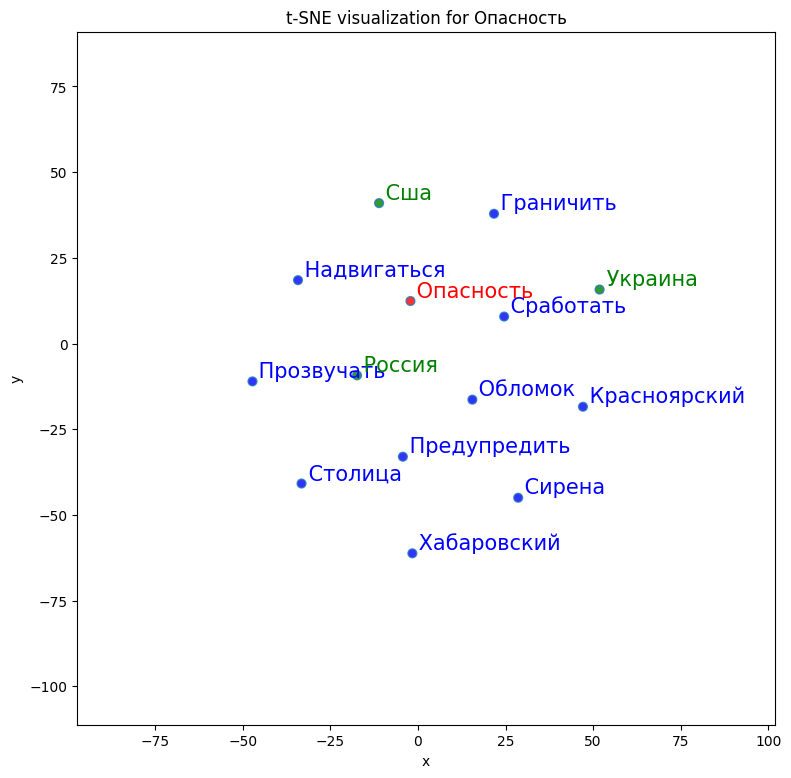

In [18]:
tsne_scatterplot(w2v_model, "опасность", ["украина","сша","россия"])